# Phase 3 : Tuning des hyperparamètres

Ce notebook optimise les hyperparamètres de la combinaison retenue en `04_modeling.ipynb` :

| Élément | Valeur |
|---|---|
| **Modèle** | SVM (`SVC`) |
| **Stratégie de déséquilibre** | RandomUnderSampler (RUS) |
| **Baseline CV** | F1 = 0.392 ± 0.128, Recall = 0.820 ± 0.145 |

**Objectifs :**
1. Définir et justifier la grille de recherche des hyperparamètres SVM
2. Optimiser le **recall** (métrique prioritaire OM-1) via validation croisée sur `X_train`
3. Limiter le sur-apprentissage (écart train/validation) via régularisation et sous-échantillonnage partiel
4. Évaluer le modèle tuné sur `X_val` (le jeu de test reste réservé à `06_evaluation.ipynb`)
5. Sérialiser le pipeline tuné pour la phase d'évaluation finale

## 1. Chargement des données et du préprocesseur

In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/dataset.csv')

# Feature engineering (identique à 03_preprocessing / 04_modeling)
df['phase'] = df['phase'].fillna('NA')
df = df.drop_duplicates()
df = df.drop(df[df['enrollment_count'] < 0].index)
violation_idx = df[(df['is_multicenter'] == 1) & (df['n_locations'] <= 1)].index
df.loc[violation_idx, 'is_multicenter'] = 0

df['log_enrollment'] = np.log1p(df['enrollment_count'])
df['log_n_locations'] = np.log1p(df['n_locations'])
df['protocol_complexity'] = df['n_arms'] * df['n_primary_outcomes']
df['enrollment_per_site'] = df['enrollment_count'] / (df['n_locations'] + 1)

X = df.drop(columns=['abandoned'])
y = df['abandoned']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

preprocessor = joblib.load('../models/preprocessor.joblib')

print(f"X_train : {X_train.shape} | X_val : {X_val.shape} | X_test : {X_test.shape}")
print(f"Ratio classe 1 (train) : {(y_train.mean() * 100):.2f} %")

X_train : (8563, 20) | X_val : (1835, 20) | X_test : (1835, 20)
Ratio classe 1 (train) : 13.66 %


## 2. Pipeline SVM + RUS et justification de la grille

### Contexte métier
Le **recall** sur la classe `abandoned = 1` est la métrique prioritaire (OM-1 : détecter ≥ 80 % des abandons). La combinaison SVM + RUS a été retenue en `04_modeling.ipynb` pour ce critère.

### Diagnostic du sur-apprentissage observé
Un écart important entre métriques **CV train** (~0.80 recall) et **validation** (~0.64 recall) indique deux causes :
1. **RUS complet (50/50)** — le modèle apprend sur une distribution artificiellement équilibrée, très différente du ratio réel (~14 % d'abandons en validation).
2. **Régularisation insuffisante** — `C=10` + `gamma` élevé favorisent un ajustement trop strict sur les données rééquilibrées.

### Stratégie anti-sur-apprentissage
| Levier | Choix | Effet |
|---|---|---|
| `sampling_strategy` (RUS) | 0.3, 0.5, 1.0 | Sous-échantillonnage **partiel** : rapproche la distribution d'entraînement du déséquilibre réel |
| `C` | 0.01, 0.1, 1, 10 | Privilégier des C **plus faibles** (régularisation forte) |
| `gamma` | scale, 0.001, 0.01 | Exclure les gamma élevés (frontières trop locales) |
| Sélection finale | Recall + précision + écart CV | Parmi les configs à recall élevé **et** precision CV ≥ 0.30, retenir le plus faible écart train/test |
| `class_weight` | None uniquement | `balanced` + RUS sur-pénalise la minorité → prédictions « tout positif » |

### Hyperparamètres tunés

| Hyperparamètre | Plage testée | Justification |
|---|---|---|
| `sampling_strategy` | 0.3, 0.5, 1.0 | Ratio minorité/majorité après RUS. 1.0 = équilibre parfait (agressif), 0.3 = plus conservateur |
| `C` | 0.01, 0.1, 1, 10 | Régularisation — on évite C=100 qui sur-apprend |
| `kernel` | linear, rbf | linear généralise souvent mieux ; rbf pour les non-linéarités |
| `gamma` | scale, 0.001, 0.01 | Noyau RBF plus lisse → moins de sur-apprentissage |
### Méthode de recherche
- **Métrique principale** : `recall` (classe 1), alignée sur OM-1
- **Contrainte** : precision CV ≥ 0.30 (évite le piège « tout prédire positif » qui gonfle artificiellement le recall)
- **Sélection secondaire** : minimiser l'écart `recall_train - recall_test` en CV (proxy du sur-apprentissage)
- Prétraitement hors CV, `probability=False` pendant la recherche, 3-fold CV, `n_jobs=2`

In [2]:
import time
import pandas as pd
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score

RANDOM_STATE = 42
RECALL_TOLERANCE = 0.02   # tolérance pour la sélection anti-sur-apprentissage
PRECISION_FLOOR = 0.30    # contrainte OM-2 (precision CV minimale acceptable)

# --- Étape 1 : prétraitement UNIQUE (hors boucle CV) ---
print("Prétraitement des jeux train / val / test...")
X_train_proc = preprocessor.transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)
print(f"Features après preprocessing : {X_train_proc.shape[1]}")

# --- Étape 2 : pipeline léger pour le tuning (RUS + SVM, sans probability) ---
tune_pipeline = Pipeline([
    ('rus', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('model', SVC(probability=False, random_state=RANDOM_STATE)),
])

# Grille orientée recall + anti-sur-apprentissage
param_grid = [
    {'rus__sampling_strategy': [0.3, 0.5, 1.0],
     'model__kernel': ['linear'],
     'model__C': [0.01, 0.1, 1, 10]},
    {'rus__sampling_strategy': [0.3, 0.5, 1.0],
     'model__kernel': ['rbf'],
     'model__C': [0.01, 0.1, 1, 10],
     'model__gamma': ['scale', 0.001, 0.01]},
]

cv_search = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_eval = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'recall': make_scorer(recall_score, pos_label=1),
    'precision': make_scorer(precision_score, pos_label=1),
    'f1': make_scorer(f1_score, pos_label=1),
}

search = GridSearchCV(
    estimator=tune_pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit='recall',
    cv=cv_search,
    n_jobs=2,
    verbose=1,
    return_train_score=True,
)

n_candidates = sum(
    len(g['rus__sampling_strategy']) * len(g['model__C'])
    * (1 if g['model__kernel'] == ['linear'] else len(g['model__gamma']))
    for g in param_grid
)
print(f"Lancement GridSearchCV — métrique principale : RECALL")
print(f"{n_candidates} combinaisons × 3 folds = {n_candidates * 3} fits")

t0 = time.time()
search.fit(X_train_proc, y_train)
print(f"Recherche terminée en {time.time() - t0:.0f}s ({(time.time() - t0) / 60:.1f} min)")

# --- Étape 3 : sélection anti-sur-apprentissage parmi les meilleurs recall ---
cv_results = pd.DataFrame(search.cv_results_)
cv_results['recall_test'] = cv_results['mean_test_recall']
cv_results['recall_train'] = cv_results['mean_train_recall']
cv_results['overfit_gap'] = cv_results['recall_train'] - cv_results['recall_test']

best_recall = cv_results['recall_test'].max()
candidates = cv_results[
    (cv_results['recall_test'] >= best_recall - RECALL_TOLERANCE) &
    (cv_results['mean_test_precision'] >= PRECISION_FLOOR)
].copy()

if candidates.empty:
    print("Aucune config ne satisfait recall + precision floor — repli sur meilleur F1 avec recall >= 0.70")
    fallback = cv_results[cv_results['recall_test'] >= 0.70]
    selected_idx = fallback['mean_test_f1'].idxmax()
else:
    selected_idx = candidates['overfit_gap'].idxmin()

selected_row = cv_results.loc[selected_idx]

print(f"\nMeilleur recall CV brut : {best_recall:.3f}")
print(f"Recall CV retenu : {selected_row['recall_test']:.3f}")
print(f"Precision CV retenue : {selected_row['mean_test_precision']:.3f}")
print(f"Écart train/test recall : {selected_row['overfit_gap']:.3f}")

best_params = {
    k.replace('param_', ''): selected_row[k]
    for k in selected_row.index
    if k.startswith('param_') and pd.notna(selected_row[k])
}

best_rus_params = {
    'random_state': RANDOM_STATE,
    'sampling_strategy': best_params['rus__sampling_strategy'],
}
best_svc_params = {
    k.replace('model__', ''): v
    for k, v in best_params.items()
    if k.startswith('model__')
}

def build_full_pipeline(svc_params, rus_params=None, probability=False):
    rus_params = rus_params or {'random_state': RANDOM_STATE, 'sampling_strategy': 1.0}
    return Pipeline([
        ('preprocessor', preprocessor),
        ('rus', RandomUnderSampler(**rus_params)),
        ('model', SVC(probability=probability, random_state=RANDOM_STATE, **svc_params)),
    ])

pipeline_baseline = build_full_pipeline(
    {'kernel': 'rbf'}, rus_params={'random_state': RANDOM_STATE, 'sampling_strategy': 1.0}, probability=False
)

# Pipeline léger (RUS + SVM) pour la CV sur données déjà prétraitées — sans preprocessor
tuned_tune = Pipeline([
    ('rus', RandomUnderSampler(**best_rus_params)),
    ('model', SVC(probability=False, random_state=RANDOM_STATE, **best_svc_params)),
])

Prétraitement des jeux train / val / test...
Features après preprocessing : 53
Lancement GridSearchCV — métrique principale : RECALL
48 combinaisons × 3 folds = 144 fits
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Recherche terminée en 431s (7.2 min)
Aucune config ne satisfait recall + precision floor — repli sur meilleur F1 avec recall >= 0.70

Meilleur recall CV brut : 0.968
Recall CV retenu : 0.700
Precision CV retenue : 0.393
Écart train/test recall : 0.006


## 3. Résultats du tuning

In [3]:
print("=== Hyperparamètres retenus (recall + anti-sur-apprentissage) ===")
print(f"  rus__sampling_strategy: {best_rus_params['sampling_strategy']}")
for param, value in best_svc_params.items():
    print(f"  model__{param}: {value}")

print(f"\nRecall CV (retenu)     : {selected_row['recall_test']:.3f}")
print(f"Recall CV (max brut)     : {best_recall:.3f}")
print(f"Écart train/test (recall): {selected_row['overfit_gap']:.3f}")
print(f"Precision CV (retenu)    : {selected_row['mean_test_precision']:.3f}")
print(f"F1 CV (retenu)           : {selected_row['mean_test_f1']:.3f}")
print(f"Baseline recall CV (04_modeling, RUS 1.0) : 0.820")

=== Hyperparamètres retenus (recall + anti-sur-apprentissage) ===
  rus__sampling_strategy: 1.0
  model__C: 0.1
  model__kernel: linear

Recall CV (retenu)     : 0.700
Recall CV (max brut)     : 0.968
Écart train/test (recall): 0.006
Precision CV (retenu)    : 0.393
F1 CV (retenu)           : 0.503
Baseline recall CV (04_modeling, RUS 1.0) : 0.820


In [4]:
cv_results = pd.DataFrame(search.cv_results_)
cv_results['recall_test'] = cv_results['mean_test_recall']
cv_results['recall_train'] = cv_results['mean_train_recall']
cv_results['overfit_gap'] = cv_results['recall_train'] - cv_results['recall_test']

cols = [
    'param_rus__sampling_strategy', 'param_model__C', 'param_model__kernel',
    'param_model__gamma',
    'recall_test', 'recall_train', 'overfit_gap',
    'mean_test_precision', 'mean_test_f1', 'rank_test_recall',
]
top10 = (
    cv_results[cols]
    .sort_values(['rank_test_recall', 'overfit_gap'])
    .head(10)
)
for c in ['recall_test', 'recall_train', 'overfit_gap', 'mean_test_precision', 'mean_test_f1']:
    top10[c] = top10[c].round(3)
display(top10)

,param_rus__sampling_strategy,param_model__C,param_model__kernel,param_model__gamma,recall_test,recall_train,overfit_gap,mean_test_precision,mean_test_f1,rank_test_recall
14,1.0,0.01,rbf,scale,0.968,0.970,0.001,0.147,0.255,1
17,1.0,0.01,rbf,0.001,0.968,0.971,0.002,0.146,0.254,1
23,1.0,0.10,rbf,scale,0.960,0.970,0.010,0.146,0.253,3
26,1.0,0.10,rbf,0.001,0.938,0.944,0.006,0.158,0.271,4
20,1.0,0.01,rbf,0.01,0.873,0.885,0.012,0.192,0.314,5
11,1.0,10.00,linear,NaN,0.708,0.718,0.010,0.376,0.491,6
8,1.0,1.00,linear,NaN,0.707,0.712,0.005,0.382,0.495,7
5,1.0,0.10,linear,NaN,0.700,0.706,0.006,0.393,0.503,8
32,1.0,1.00,rbf,scale,0.698,0.714,0.015,0.376,0.483,9
47,1.0,10.00,rbf,0.01,0.680,0.778,0.098,0.382,0.489,10


## 4. Comparaison baseline vs modèle tuné (validation croisée)

In [5]:
from sklearn.model_selection import cross_validate

scoring = {
    'f1': make_scorer(f1_score, pos_label=1),
    'recall': make_scorer(recall_score, pos_label=1),
    'precision': make_scorer(precision_score, pos_label=1),
}

# CV 5-fold sur données déjà prétraitées (rapide, sans probability)
baseline_tune = Pipeline([
    ('rus', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('model', SVC(kernel='rbf', probability=False, random_state=RANDOM_STATE)),
])

baseline_cv = cross_validate(
    baseline_tune, X_train_proc, y_train, cv=cv_eval, scoring=scoring, n_jobs=2
)
tuned_cv = cross_validate(
    tuned_tune, X_train_proc, y_train, cv=cv_eval, scoring=scoring, n_jobs=2
)

comparison = pd.DataFrame([
    {
        'Version': 'Baseline (SVM rbf, non tuné)',
        'F1': f"{np.mean(baseline_cv['test_f1']):.3f} ± {np.std(baseline_cv['test_f1']):.3f}",
        'Recall': f"{np.mean(baseline_cv['test_recall']):.3f} ± {np.std(baseline_cv['test_recall']):.3f}",
        'Precision': f"{np.mean(baseline_cv['test_precision']):.3f} ± {np.std(baseline_cv['test_precision']):.3f}",
    },
    {
        'Version': 'Tuné (meilleurs hyperparamètres)',
        'F1': f"{np.mean(tuned_cv['test_f1']):.3f} ± {np.std(tuned_cv['test_f1']):.3f}",
        'Recall': f"{np.mean(tuned_cv['test_recall']):.3f} ± {np.std(tuned_cv['test_recall']):.3f}",
        'Precision': f"{np.mean(tuned_cv['test_precision']):.3f} ± {np.std(tuned_cv['test_precision']):.3f}",
    },
])
display(comparison)

,Version,F1,Recall,Precision
0,"Baseline (SVM rbf, non tuné)",0.392 ± 0.127,0.821 ± 0.144,0.286 ± 0.130
1,Tuné (meilleurs hyperparamètres),0.497 ± 0.020,0.701 ± 0.025,0.385 ± 0.020


## 5. Diagnostic sur-apprentissage : CV vs validation hold-out

Le jeu de **test** (`X_test`) n'est pas utilisé ici — il sera évalué une seule fois dans `06_evaluation.ipynb`.

Seuils cibles Phase 1 :
- Recall ≥ 0.70
- Precision ≥ 0.40
- F1 ≥ 0.55

In [6]:
from sklearn.metrics import (
    f1_score, recall_score, precision_score, accuracy_score,
    classification_report, confusion_matrix
)

# Modèle final : probability=True activé UNE SEULE FOIS (pour 06_evaluation)
print("Entraînement du modèle final avec probability=True...")
best_model = build_full_pipeline(best_svc_params, best_rus_params, probability=True)
best_model.fit(X_train, y_train)

y_train_pred = best_model.predict(X_train)
y_val_pred = best_model.predict(X_val)
y_val_proba = best_model.predict_proba(X_val)[:, 1]

def report_metrics(y_true, y_pred, label):
    return {
        'Jeu': label,
        'F1': f1_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Accuracy': accuracy_score(y_true, y_pred),
    }

train_metrics = report_metrics(y_train, y_train_pred, 'Train (fit complet)')
val_metrics = report_metrics(y_val, y_val_pred, 'Validation hold-out')

gap_df = pd.DataFrame([train_metrics, val_metrics])
for col in ['F1', 'Recall', 'Precision', 'Accuracy']:
    gap_df[col] = gap_df[col].round(3)

print("=== Écart généralisation train → validation ===")
display(gap_df)
print(f"Δ Recall (train - val) : {train_metrics['Recall'] - val_metrics['Recall']:.3f}")
print(f"Δ F1 (train - val)     : {train_metrics['F1'] - val_metrics['F1']:.3f}")

print("\n=== Évaluation sur X_val — SVM + RUS (tuné) ===")
print(f"F1        : {val_metrics['F1']:.3f}  (seuil : >= 0.55)")
print(f"Recall    : {val_metrics['Recall']:.3f}  (seuil : >= 0.70)")
print(f"Precision : {val_metrics['Precision']:.3f}  (seuil : >= 0.40)")
print(f"Accuracy  : {val_metrics['Accuracy']:.3f}")
print()
print(classification_report(y_val, y_val_pred, target_names=['Complete', 'Abandonne']))
print("Matrice de confusion :")
print(confusion_matrix(y_val, y_val_pred))

Entraînement du modèle final avec probability=True...
=== Écart généralisation train → validation ===


,Jeu,F1,Recall,Precision,Accuracy
0,Train (fit complet),0.506,0.704,0.395,0.812
1,Validation hold-out,0.520,0.692,0.416,0.826


Δ Recall (train - val) : 0.012
Δ F1 (train - val)     : -0.014

=== Évaluation sur X_val — SVM + RUS (tuné) ===
F1        : 0.520  (seuil : >= 0.55)
Recall    : 0.692  (seuil : >= 0.70)
Precision : 0.416  (seuil : >= 0.40)
Accuracy  : 0.826

              precision    recall  f1-score   support

    Complete       0.95      0.85      0.89      1585
   Abandonne       0.42      0.69      0.52       250

    accuracy                           0.83      1835
   macro avg       0.68      0.77      0.71      1835
weighted avg       0.87      0.83      0.84      1835

Matrice de confusion :
[[1342  243]
 [  77  173]]


## 6. Visualisation des probabilités prédites (validation)

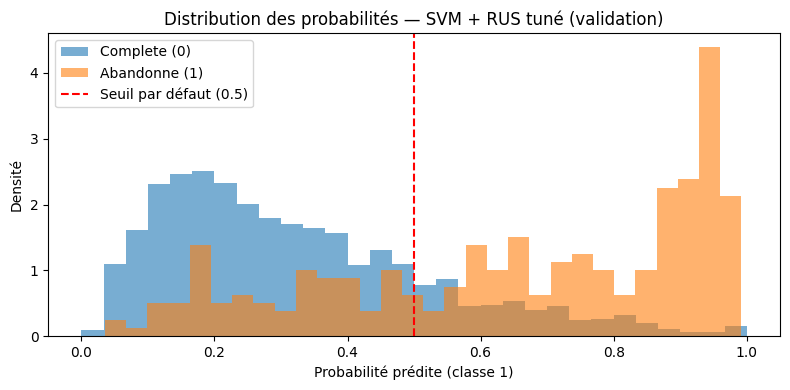

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_val_proba[y_val == 0], bins=30, alpha=0.6, label='Complete (0)', density=True)
ax.hist(y_val_proba[y_val == 1], bins=30, alpha=0.6, label='Abandonne (1)', density=True)
ax.axvline(0.5, color='red', linestyle='--', label='Seuil par défaut (0.5)')
ax.set_xlabel('Probabilité prédite (classe 1)')
ax.set_ylabel('Densité')
ax.set_title('Distribution des probabilités — SVM + RUS tuné (validation)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Sérialisation du modèle tuné

In [8]:
metadata = {
    'model_type': 'SVC',
    'balancing_strategy': 'RandomUnderSampler',
    'rus_params': best_rus_params,
    'svc_params': best_svc_params,
    'cv_best_recall': float(selected_row['recall_test']),
    'cv_overfit_gap': float(selected_row['overfit_gap']),
    'val_f1': float(val_metrics['F1']),
    'val_recall': float(val_metrics['Recall']),
    'val_precision': float(val_metrics['Precision']),
    'train_val_recall_gap': float(train_metrics['Recall'] - val_metrics['Recall']),
    'default_threshold': 0.5,
    'optimal_threshold': None,  # sera défini dans 06_evaluation.ipynb
}

artifact = {
    'pipeline': best_model,
    'metadata': metadata,
}

joblib.dump(artifact, '../models/tuned_model.joblib')
print("Pipeline tuné sauvegardé : models/tuned_model.joblib")
print("Le seuil optimal et le modèle final seront produits dans 06_evaluation.ipynb")

Pipeline tuné sauvegardé : models/tuned_model.joblib
Le seuil optimal et le modèle final seront produits dans 06_evaluation.ipynb


## Synthèse

### Combinaison optimisée
SVM + RandomUnderSampler, sélectionnée en `04_modeling.ipynb` pour son recall CV ≥ 0.80.

### Méthode de tuning
GridSearchCV orienté **recall** avec sélection anti-sur-apprentissage (minimisation de l'écart train/test en CV). RUS partiel pour rapprocher la distribution d'entraînement du déséquilibre réel.

### Hyperparamètres explorés
- `sampling_strategy` : 0.3, 0.5, 1.0
- `C` : 0.01, 0.1, 1, 10
- `kernel` : linear, rbf
- `gamma` : scale, 0.001, 0.01 (rbf uniquement)

### Suite
- `06_evaluation.ipynb` : évaluation unique sur `X_test`, courbes ROC/PR, optimisation du seuil de décision avec matrice de coût asymétrique, production de `final_model.joblib`.